## Compito Esame

Data la funzione:

<h2>$f(x)=\frac{\sin^2(x + 7/2)e^{(1/5-2x)}}{\log(x+5)}$
</h2>

a) Si disegna il grafico e si indica quanti 0 ha la funzione nell'intervallo [-2, 4]

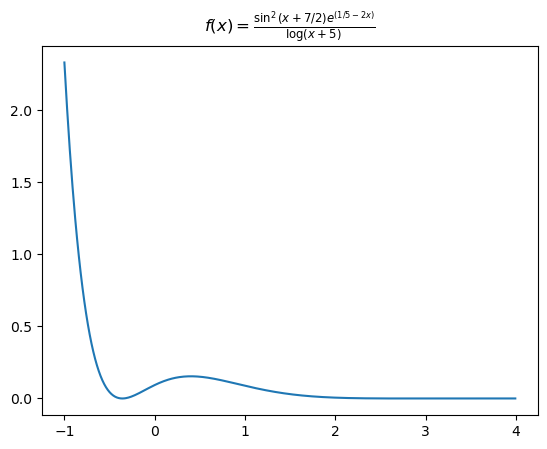

In [61]:
import sympy as sym
import numpy as np
from sympy.utilities.lambdify import lambdify
import matplotlib.pyplot as plt

r = np.arange(-1, 4, 0.01)
f = lambda x: (sym.sin(x + 7/2)**2*sym.exp(1/5-2*x))/sym.log(x+5)
x = sym.Symbol('x')
func = lambdify(x, f(x), np)
plt.plot(r, func(r))
plt.title(r"$f(x)=\frac{\sin^2(x + 7/2)e^{(1/5-2x)}}{\log(x+5)}$")
plt.show()

Si utilizzi il metodo di newton per trovare gli zeri avendo come iterati iniziali x0 = -1, x0 = 4
tolf = 1.e-15 and tolx = 1.e-15

In [31]:
from itertools import takewhile
tolf = 1e-15
tolx = 1e-15
nmax = 500

def iterate(func, start):
    while True:
        yield start
        start = func(start)

def newton(f, dx, x0, tolx, tolf, nmax, delta):
    stop_criteria = lambda i, x: i < nmax and abs(delta(f, dx, x)) >= tolx and abs(f(x)) >= tolf

    iter = iterate(lambda xk: xk - delta(f, dx, xk), x0)
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) \
        + [next(iter)]

    return arr[-1], len(arr), arr


In [52]:
m = 1
dx = lambdify(x, sym.diff(f(x), x, m), np)
init_0 = [-1, 4]
sol = [newton(func, dx, x0, tolx, tolf, nmax, lambda f, dx, x: f(x)/dx(x)) for x0 in init_0]
[print(f"Zeri di funzione: {z}") for z, _,_ in sol]

Zeri di funzione: -0.35840735355377573
Zeri di funzione: 5.924772543716909


[None, None]

Si diesgni l'andamento degli iterati a partire da x0 = 4 e x0 = -1

[[<matplotlib.lines.Line2D at 0x7bf898f61790>],

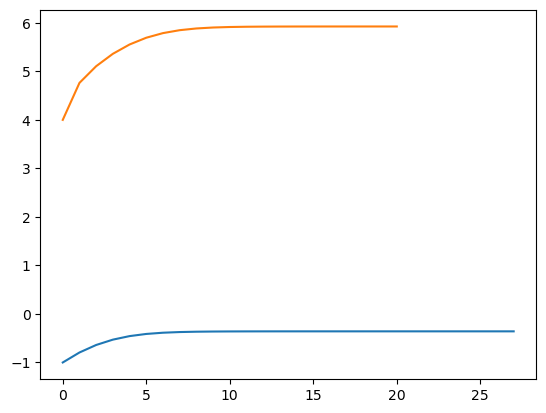

In [35]:
[plt.plot(range(i), a) for _, i, a in sol]

Si stimi l'ordine di convergenza del metodo

In [36]:
def order_evaluation(arr, it):
    order = [
        np.log(abs(arr[k+2] - arr[k+3]) / abs(arr[k+1] - arr[k+2]))/\
        np.log(abs(arr[k+1] - arr[k+2]) / abs(arr[k] - arr[k+1]))\
        for k in range(it-3)
    ]
    return order[-1]

[order_evaluation(a, i) for _, i, a in sol]

[0.41503745038366446, 0.4150053126547633]

Modifica newton

In [55]:
m = 2
sol = [newton(func, dx, x0, tolx, tolf, nmax, lambda f, dx, x: m * f(x)/dx(x)) for x0 in init_0]
[print(f"Zeri di funzione: {z}") for z, _,_ in sol]

Zeri di funzione: -0.35840734641020694
Zeri di funzione: 5.9247779607693785


[None, None]

In [49]:
[print(f"Stima ordine: {order_evaluation(a, i)}") for _, i, a in sol]

Stima ordine: 2.0092112291051243
Stima ordine: 2.020517454161396


[None, None]

[[<matplotlib.lines.Line2D at 0x7bf898e07f50>],

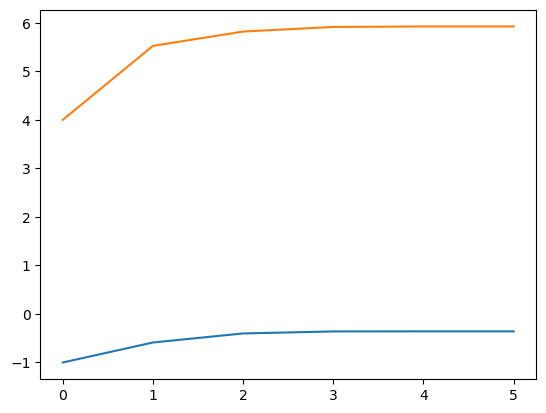

In [43]:
[plt.plot(range(i), a) for _, i, a in sol]

In [45]:
func(-0.35840734641020694)

2.4437940494587717e-32

In [46]:
func(5.9247779607693785)

4.924257031501582e-37